## **PROJETO 01**
## **Comparação de Modelos RNN na Predição de Qualidade do Ar**

### **Inicializando o Código com os Requerimentos das Bibliotecas Necessárias e a Importação do Banco de Dados**

In [ ]:
# Import as bibliotecas necessárias
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, SimpleRNN, LSTM, GRU, Dense, Bidirectional, Attention, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.linear_model import LinearRegression

# Carregando o dataset
data = pd.read_csv("/content/beijing_multi.csv",sep=";")

### **Preprocessamento dos Dados para Seleção de Variáveis, Remoção de Valores Faltantes, Normalização dos Dados, Criação de Sequências de 24h para RNN e Divisão dos Dados em Treino e Teste**

In [ ]:
# Função de Pré-processamento
def preprocess_data(data):
    # Removendo linhas com valores faltantes
    data = data.dropna()

    # Seleção das variáveis de entrada e variável-alvo
    numerical_features = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'WD']
    target = 'PM2.5'

    # Extração das características numéricas
    X = data[numerical_features].values
    y = data[target].values.reshape(-1, 1)

    # Normalização dos dados
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    X_scaled = scaler_X.fit_transform(X)
    y_scaled = scaler_y.fit_transform(y)

    # Criando as sequências de 24 horas para RNN
    def create_sequences(X, y, seq_length):
        X_seq, y_seq = [], []
        for i in range(len(X) - seq_length):
            X_seq.append(X[i:i+seq_length])
            y_seq.append(y[i+seq_length])
        return np.array(X_seq), np.array(y_seq)

    seq_length = 24  # Utilizando a sequência de 24 horas
    X_seq, y_seq = create_sequences(X_scaled, y_scaled, seq_length)

    # Divisão treino/teste (80%/20%)
    split = int(0.8 * len(X_seq))
    X_train, X_test = X_seq[:split], X_seq[split:]
    y_train, y_test = y_seq[:split], y_seq[split:]

    return X_train, X_test, y_train, y_test, scaler_y

# Preprocessamento dos Dados
X_train, X_test, y_train, y_test, scaler_y = preprocess_data(data)

### **Definição e Construção dos Modelos RNN e Variantes a Fim de Comparação de Performances (Variantes: Vanilla RNN, LSTM, GRU, Bi-RNN, e Attention-Augmented RNN)**

In [ ]:
# Definição dos modelos Vanila RNN, LSTM e Attention-Augmented RNN
def build_vanilla_rnn(input_shape):
    inputs = Input(shape=input_shape)
    x = SimpleRNN(64, activation='relu')(inputs)
    outputs = Dense(1)(x)
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model

def build_lstm(input_shape):
    inputs = Input(shape=input_shape)
    x = LSTM(64, activation='relu')(inputs)
    outputs = Dense(1)(x)
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model

def build_attention_rnn(input_shape):
    inputs = Input(shape=input_shape)
    rnn_output = LSTM(64, activation='relu', return_sequences=True)(inputs)
    attention = Attention()([rnn_output, rnn_output])
    context_vector = Concatenate()([rnn_output, attention])
    dense_output = Dense(1)(context_vector[:, -1, :])
    model = Model(inputs=inputs, outputs=dense_output)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model

### **Treinamento dos Modelos nos Dados, Avaliação de Desempenho, Predições e Métricas de Treinamento**

In [ ]:
# Definindo o treinamento e validação para os modelos
def train_and_evaluate(model, X_train, y_train, X_test, y_test, scaler_y):
    # Retorno de chamada de parada antecipada
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # Treino do modelo
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0
    )

    # Predições
    y_pred_scaled = model.predict(X_test)
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    y_true = scaler_y.inverse_transform(y_test)

    # Métricas
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    # Retorno para história e métricas
    return history, rmse, mae, r2

### **Teste dos Modelos nos Dados e Métricas de Teste**

In [ ]:
# Rodar os experimentos
models = {
    "Vanilla RNN": build_vanilla_rnn((X_train.shape[1], X_train.shape[2])),
    "LSTM": build_lstm((X_train.shape[1], X_train.shape[2])),
    "Attention-Augmented RNN": build_attention_rnn((X_train.shape[1], X_train.shape[2]))
}

# Dicionário para armazenar os histórico e as métricas
histories = {}
training_histories = {}

# Treinamento e avaliação de cada modelo
for name, model in models.items():
    print(f"Training {name}...")
    history, rmse, mae, r2 = train_and_evaluate(model, X_train, y_train, X_test, y_test, scaler_y)
    histories[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}
    training_histories[name] = history
    print(f"{name} Results: RMSE={rmse:.2f}, MAE={mae:.2f}, R2={r2:.2f}")

# Visualização dos resultados
metrics_df = pd.DataFrame(histories).T
print("\nModel Metrics:")
print(metrics_df)

Training Vanilla RNN...
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step
Vanilla RNN Results: RMSE=25.42, MAE=15.45, R2=0.91
Training LSTM...
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step
LSTM Results: RMSE=24.01, MAE=14.52, R2=0.92
Training Attention-Augmented RNN...
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step
Attention-Augmented RNN Results: RMSE=23.67, MAE=14.59, R2=0.92

Model Metrics:
                              RMSE        MAE        R2
Vanilla RNN              25.422531  15.449145  0.907453
LSTM                     24.005373  14.519631  0.917483
Attention-Augmented RNN  23.667650  14.590415  0.919789


### **Visualização das Perdas no Treino e Validação do Melhor Modelo**

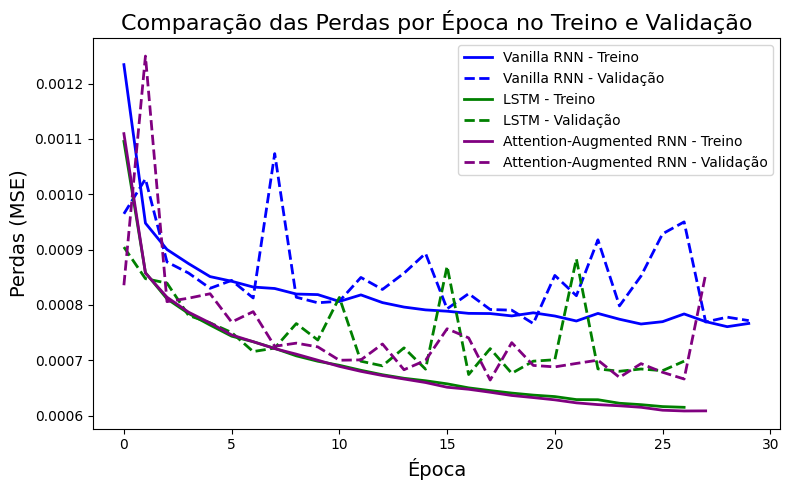

In [ ]:
# Definição de paleta de cores
colors = {
    "Vanilla RNN": "blue",
    "LSTM": "green",
    "Attention-Augmented RNN": "purple"
}

# Criando layout
plt.figure(figsize=(8, 5))

# Loop em cada modelo para plotar suas perdas de treinamento e validação
for name, history in training_histories.items():
    train_loss = history.history['loss']
    val_loss = history.history['val_loss']

    # Plotar perdas do treinamento
    plt.plot(train_loss, label=f'{name} - Treino', color=colors[name], linestyle='-', linewidth=2)

    # Plotar perdas da validação
    plt.plot(val_loss, label=f'{name} - Validação', color=colors[name], linestyle='--', linewidth=2)

# Adicionando legendas e títulos
plt.title('Comparação das Perdas por Época no Treino e Validação', fontsize=16)
plt.xlabel('Época', fontsize=14)
plt.ylabel('Perdas (MSE)', fontsize=14)
plt.legend(fontsize=10, loc='upper right', bbox_to_anchor=(1, 1))
plt.grid(False)

# Mostrando o gráfico
plt.tight_layout()
plt.show()